In [104]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import data_manager as dm

In [ ]:
class VariationalEncoder(nn.Module):
    def __init__(self, img_size=64, emb_dimension=2, *args, **kwargs):
        super().__init__(*args, **kwargs)

        def create_block(in_channels, out_channels, kernel_size=2, stride=2):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size, stride),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU()
            )
        self.emb_dimension = emb_dimension
        
        in_channels = 3
        out_channels = 128
        kernel_size = 2
        stride = 2

        self.block_1 = create_block(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride)
        self.block_2 = create_block(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride)
        self.block_3 = create_block(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride)
        self.block_4 = create_block(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride)
        self.flatten = nn.Flatten()
        in_dim = img_size * img_size // 256 * out_channels
        self.mean = nn.Linear(in_dim, emb_dimension)
        self.log_var = nn.Linear(in_dim, emb_dimension)
    
    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)
        x = self.flatten(x)

        mean = self.mean(x)
        log_var = self.log_var(x)
        
        eps = torch.randn(size=(x.shape[0], self.emb_dimension))
        x = mean + torch.exp(0.5 * log_var) * eps

        return x

In [89]:
class Decoder(nn.Module):
    def __init__(self, emb_dimension=2, img_size=64, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.img_size = img_size
        self.out_channels = 128

        out_channels = 128
        in_channels = 3
        kernel_size = 2
        stride = 2

        def create_block(in_channels, out_channels):
            return nn.Sequential(
                nn.ConvTranspose2d(in_channels, in_channels, kernel_size, stride),
                nn.BatchNorm2d(in_channels),
                nn.LeakyReLU()
            )

        in_dim = img_size * img_size // 256 * out_channels

        self.lin_1 = nn.Linear(emb_dimension, in_dim)
        self.batch_norm_1 = nn.BatchNorm1d(in_dim)
        self.leaky_relu_1 = nn.LeakyReLU()

        self.block_1 = create_block(out_channels, out_channels)
        self.block_2 = create_block(out_channels, out_channels)
        self.block_3 = create_block(out_channels, out_channels)
        self.block_4 = create_block(out_channels, out_channels)

        self.final_conv2d = nn.ConvTranspose2d(out_channels, in_channels, 1, 1)
    
    def forward(self, x):

        x = self.lin_1(x)
        x = self.batch_norm_1(x)
        x = self.leaky_relu_1(x)

        x = torch.reshape(x, (-1, self.out_channels, self.img_size // 16, self.img_size // 16))

        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)

        x = self.final_conv2d(x)

        return x



In [122]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, img_size, emb_dimension, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.img_size = img_size
        self.emb_dimension = emb_dimension
        
        self.encoder = VariationalEncoder(img_size, emb_dimension)
        self.decoder = Decoder(emb_dimension, img_size)
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [119]:
class ImageFolderDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_files = [
            f for f in os.listdir(folder_path) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
        ]
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.image_files[idx])
        img = Image.open(img_path).convert('RGB')  # Ensure 3 channels
        
        if self.transform:
            img = self.transform(img)
        
        return img

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1] range
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = ImageFolderDataset(
    folder_path=dm.full_dataset_path(),
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

In [143]:
img_size = 64
emb_dim = 7
criterion = nn.MSELoss()
model = VariationalAutoencoder(img_size, emb_dim)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 5

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_results(model, dataloader, epoch, latent_dim=2, num_samples=5):
    model.eval()
    with torch.no_grad():
        test_images = next(iter(dataloader))[:num_samples]
        reconstructions = model(test_images)
        
        random_z = torch.randn(num_samples, latent_dim)
        generated_images = model.decoder(random_z)
        
        fig, axes = plt.subplots(3, num_samples, figsize=(15, 6))
        
        for i in range(num_samples):
            axes[0, i].imshow(test_images[i].permute(1, 2, 0).cpu().numpy().clip(0, 1))
            axes[0, i].set_title("Original")
            axes[0, i].axis('off')
            
            axes[1, i].imshow(reconstructions[i].permute(1, 2, 0).cpu().numpy().clip(0, 1))
            axes[1, i].set_title("Reconstructed")
            axes[1, i].axis('off')
            
            axes[2, i].imshow(generated_images[i].permute(1, 2, 0).cpu().numpy().clip(0, 1))
            axes[2, i].set_title("Generated")
            axes[2, i].axis('off')
        
        plt.suptitle(f"Epoch {epoch + 1} Results")
        plt.tight_layout()
        
        os.makedirs("results", exist_ok=True)
        plt.savefig(f"results/epoch_{epoch+1}.png")
        plt.show()
    
    model.train()

In [149]:
def train_one_epoch(epoch_index):
    for i, images in enumerate(dataloader):
        if i % 100 == 0:
            print(f'{i}/{len(dataloader)}')
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(images, outputs)
        loss.backward()
        optimizer.step()

### EPOCH 1 / 5 ###
0/933
100/933
200/933
300/933
400/933
500/933
600/933
700/933
800/933
900/933


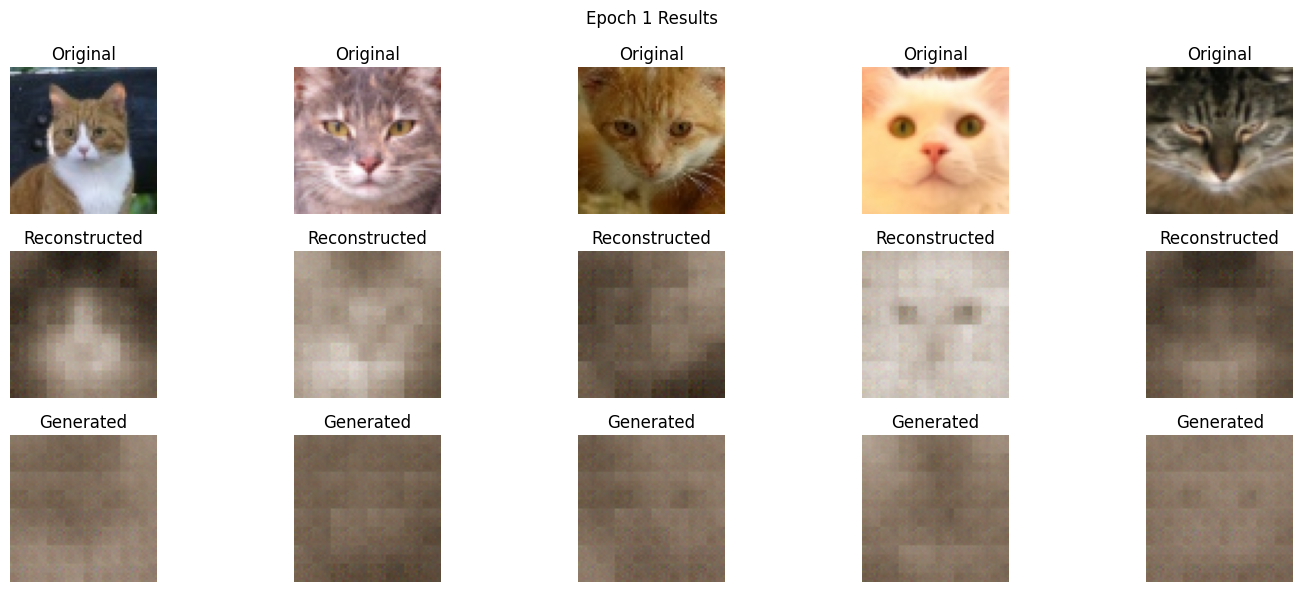

### EPOCH 2 / 5 ###
0/933


KeyboardInterrupt: 

In [150]:
for epoch in range(num_epochs):
    print(f'### EPOCH {epoch + 1} / {num_epochs} ###')
    train_one_epoch(epoch)
    visualize_results(model, dataloader, epoch, latent_dim=emb_dim, num_samples=5)